In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [8]:
df = pd.read_csv("thyroid1_dataset.csv")

In [9]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,49.0,3.0,5.0,116.0,4.0,o


In [10]:
X = df.drop("Outlier_label",axis=1)
y = df["Outlier_label"]

In [11]:
X.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,61.0,6.0,23.0,87.0,26.0
1,0.61,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29.0,15.0,61.0,96.0,64.0
2,0.16,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,29.0,19.0,58.0,103.0,56.0
3,0.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,114.0,3.0,24.0,61.0,39.0
4,0.75,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,49.0,3.0,5.0,116.0,4.0


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators=200,contamination='auto',random_state=42)

In [14]:
labels = clf.fit_predict(X_scaled)

In [15]:
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [16]:
# visulized
from sklearn.decomposition import PCA

pca =PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'PC2')

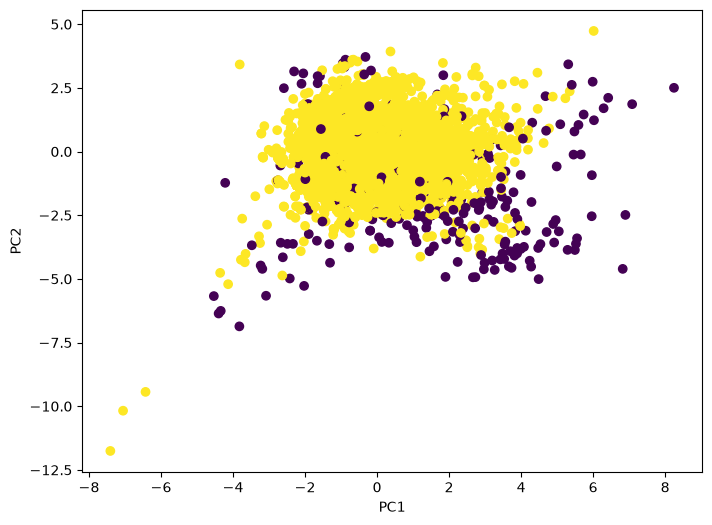

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0],X_pca[:, 1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [18]:
import numpy as np

n_outliers =np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("outliers: ",n_outliers)
print("normal: ",n_normal)

outliers:  270
normal:  6646


# LOF

In [19]:
from sklearn.neighbors import LocalOutlierFactor

In [20]:
neighbs = LocalOutlierFactor(contamination = 0.036)

labels = neighbs.fit_predict(X_scaled)

Text(0, 0.5, 'PC2')

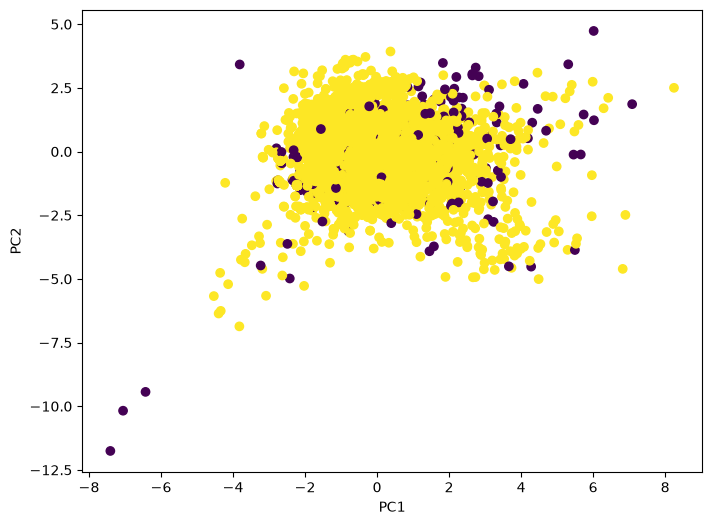

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:, 0],X_pca[:, 1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [22]:
import numpy as np

n_outliers =np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("outliers: ",n_outliers)
print("normal: ",n_normal)

outliers:  249
normal:  6667
